# Clusterização dos Municípios Paulistas

Objetivo:
Agrupar os municípios do estado de São Paulo em perfis semelhantes considerando:

- Índice de Desenvolvimento em Saúde (IDS)
- Receita anual
- População

A análise busca identificar diferentes níveis de desenvolvimento e potenciais cenários de pressão sobre os serviços públicos de saúde.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### 1. Leitura do Dataset

In [17]:
df = pd.read_csv(
    "data/processed/main_dataframe.csv",
    sep=";"
)

### 2. Variáveis utilizadas na clusterização

Foram utilizadas três variáveis:

- IDS
- Receita anual
- População

Essas variáveis representam simultaneamente aspectos de desenvolvimento em saúde, capacidade econômica e porte populacional dos municípios.

In [18]:
FEATURES = [
    "ids",
    "receita_anual",
    "populacao"
]

X = df[FEATURES].copy()

### 3. Clusterização considerando todos os municípios

Primeiramente será realizada a clusterização utilizando todos os
municípios do estado, incluindo a capital paulista.

In [19]:
X = df[FEATURES].copy()

### 4. Normalização

Como as variáveis possuem escalas muito diferentes, foi aplicada a padronização utilizando StandardScaler.

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 5. Aplicação do K-Means (4 clusters)

In [21]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

### 6. Avaliação dos agrupamentos

A qualidade dos clusters foi avaliada utilizando o Silhouette Score.

In [22]:
silhouette = silhouette_score(
    X_scaled,
    df["cluster"]
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.4842


Valores próximos de 1 indicam grupos bem separados. Valores próximos de 0 indicam sobreposição entre clusters.

### 7. Perfil estatístico dos clusters

In [23]:
profile = (
    df.groupby("cluster")[FEATURES]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

profile

ids                    receita_anual                              \
         mean median   min   max          mean        median           min   
cluster                                                                      
0        0.73   0.71  0.62  0.97  6.092459e+08  2.122639e+08  2.499808e+07   
1        0.74   0.74  0.74  0.74  9.578991e+10  9.578991e+10  9.578991e+10   
2        0.32   0.33  0.13  0.45  1.697973e+08  5.069474e+07  1.361518e+06   
3        0.57   0.58  0.45  0.66  1.736573e+08  6.949144e+07  1.443219e+07   

                         populacao                                  
                  max         mean      median       min       max  
cluster                                                             
0        8.143600e+09     89543.18     33847.5      1290   1223237  
1        9.578991e+10  12396372.00  12396372.0  12396372  12396372  
2        6.192621e+09     38576.96      7905.0       839   1404694  
3        2.379475e+09     32737.46     12639.0      1142    455587

### 8. Quantidade de municípios por Cluster

In [36]:
df["cluster"] \
    .value_counts() \
    .sort_index()

cluster
0    212
1      1
2    193
3    239
Name: count, dtype: int64

In [43]:
cluster = 0
dados = (
    df[
        df["cluster"] == cluster
    ]
    .sort_values(
        by=["ids", "receita_anual"],
        ascending=False
    )
)

dados[
    [
        "municipio",
        "ids",
        "receita_anual",
        "populacao"
    ]
].head(10)

,municipio,ids,receita_anual,populacao
545,SAO CAETANO DO SUL,0.966,2.042468e+09,162763
636,VINHEDO,0.924,8.123369e+08,81516
542,SANTOS,0.912,4.284191e+09,433991
293,JUNDIAI,0.894,3.664002e+09,426935
234,ILHA SOLTEIRA,0.875,2.346250e+08,26886
521,SANTA FE DO SUL,0.873,2.948873e+08,32796
0,ADAMANTINA,0.872,2.688760e+08,35153
302,LENCOIS PAULISTA,0.864,4.798066e+08,69533
548,SAO JOAO DA BOA VISTA,0.852,5.967856e+08,92315
629,VALINHOS,0.851,9.722731e+08,133169


### 9. Representação gráfica

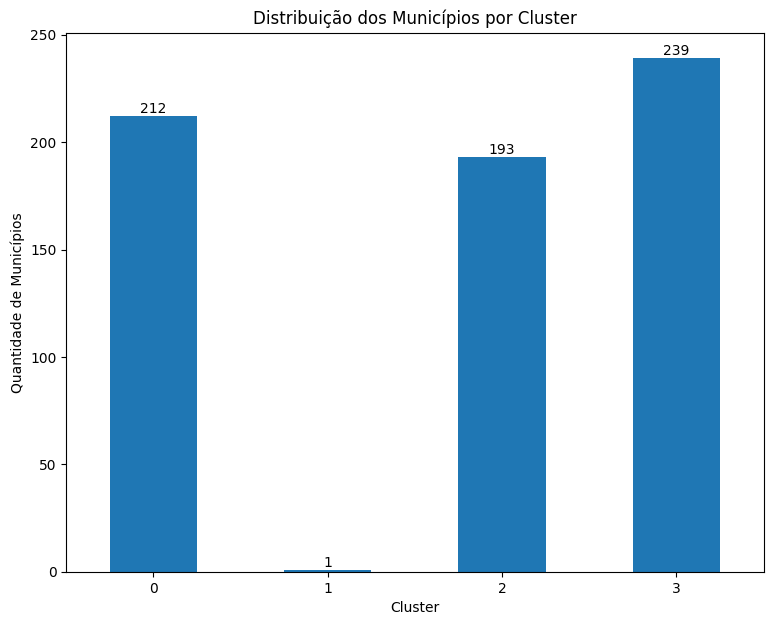

In [25]:
plt.figure(figsize=(9,7))

ax = (
    df["cluster"]
    .value_counts()
    .sort_index()
    .plot(kind="bar")
)

plt.title("Distribuição dos Municípios por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de Municípios")
plt.xticks(rotation=0)

for barra in ax.patches:
    altura = barra.get_height()

    ax.annotate(
        f"{int(altura)}",
        (
            barra.get_x() + barra.get_width()/2,
            altura
        ),
        ha="center",
        va="bottom"
    )

plt.show()

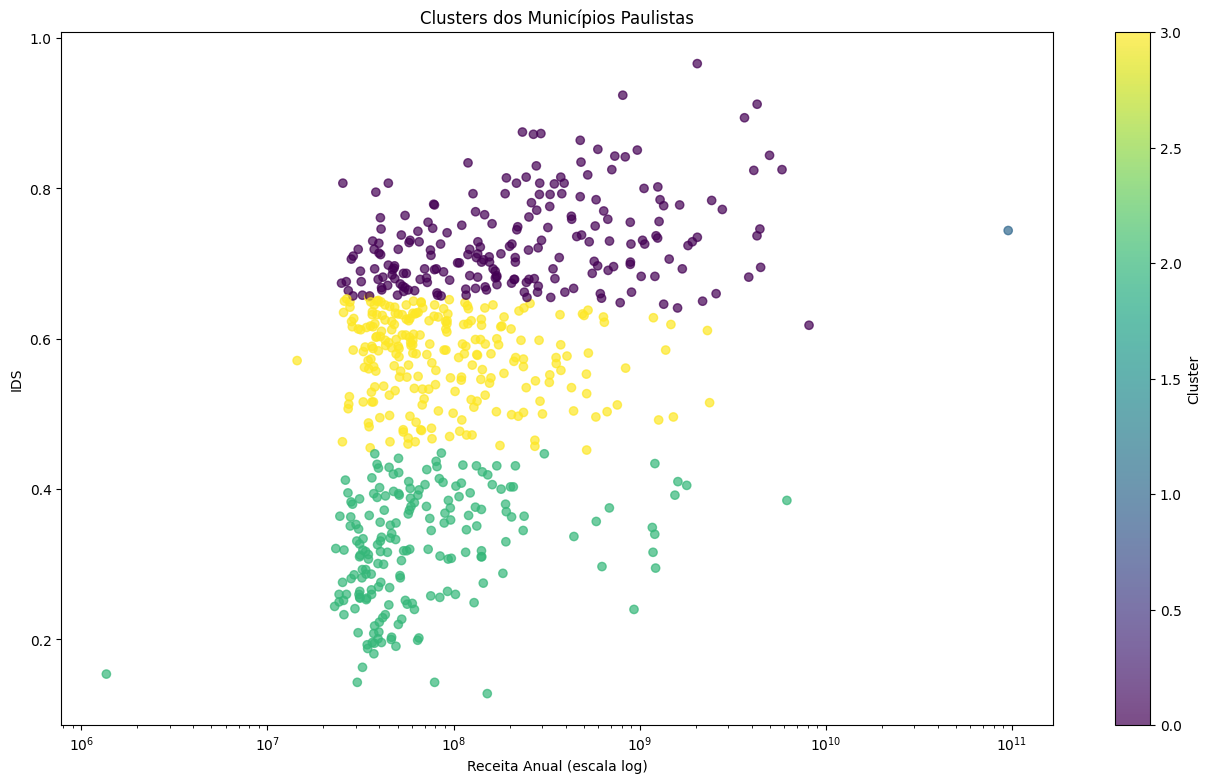

In [26]:
plt.figure(figsize=(16,9))

scatter = plt.scatter(
    df["receita_anual"],
    df["ids"],
    c=df["cluster"],
    alpha=0.7
)

plt.xscale("log")

plt.title("Clusters dos Municípios Paulistas")
plt.xlabel("Receita Anual (escala log)")
plt.ylabel("IDS")
plt.colorbar(scatter, label="Cluster")

plt.show()

## Conclusão Intermediária:

aaaaa

## Parte 2 do experimento: Remoção do município de São Paulo

O município de São Paulo apresenta valores muito superiores aos demais municípios em termos de população e receita anual, caracterizando-se como um outlier. Portanto, uma segunda análise é realizada sem sua presença.

In [27]:
df_without_sp = df[
    df["municipio"] != "SAO PAULO"
].copy()

### Normalização

In [28]:
X = df_without_sp[FEATURES]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Aplicação do K-Means

In [29]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_without_sp["cluster"] = kmeans.fit_predict(
    X_scaled
)

### Avaliação do Silhouette Score

In [30]:
silhouette = silhouette_score(
    X_scaled,
    df_without_sp["cluster"]
)

print(
    f"Silhouette Score: {silhouette:.4f}"
)

Silhouette Score: 0.5644


Observar mudança do valor acima.

### 7. Perfil estatístico dos clusters

In [31]:
profile = (
    df_without_sp
    .groupby("cluster")[FEATURES]
    .agg([
        "mean",
        "median",
        "min",
        "max"
    ])
    .round(2)
)

profile

ids                    receita_anual                              \
         mean median   min   max          mean        median           min   
cluster                                                                      
0        0.65   0.65  0.50  0.92  1.833916e+08  9.408158e+07  1.443219e+07   
1        0.61   0.65  0.24  0.97  1.503557e+09  1.347853e+09  7.592513e+08   
2        0.74   0.75  0.38  0.91  4.933553e+09  4.433108e+09  3.664002e+09   
3        0.34   0.35  0.13  0.50  8.316483e+07  5.091069e+07  1.361518e+06   

                       populacao                             
                  max       mean    median     min      max  
cluster                                                      
0        1.288563e+09   30042.05   15799.5    1142   158438  
1        2.784507e+09  272593.41  256915.0  114508   481725  
2        8.143600e+09  745136.91  720116.0  279704  1404694  
3        6.880922e+08   16208.86    7883.5     839   198661

### 8. Tamanho de cada cluster

In [32]:
df_without_sp["cluster"] \
    .value_counts() \
    .sort_index()

cluster
0    382
1     41
2     11
3    210
Name: count, dtype: int64

### 9. Municipios de cada cluster

In [44]:
cluster = 0

dados = (
    df_without_sp[
        df_without_sp["cluster"] == cluster
    ]
    .sort_values(
        by=["ids", "receita_anual"],
        ascending=False
    )
)

dados.head(10)

,municipio,latitude,longitude,hospital_estadual,hospital_federal,hospital_municipal,hospital_particular,clinica_estadual,clinica_federal,clinica_municipal,...,outras cirurgias,"coleta e exames para fins de doacao de orgaos, tecidos e celulas e de transplante",acoes relacionadas a doacao de orgaos e tecidos para transplante,processamento de tecidos para transplante,"transplante de orgaos, tecidos e celulas",avaliacao de morte encefalica,populacao,receita_anual,ids,cluster
636,VINHEDO,"-23,0302","-46,9833",0,0,0,1,0,0,5,...,9,0,0,0,0,0,81516,8.123369e+08,0.924,0
234,ILHA SOLTEIRA,"-20,4326","-51,3426",0,0,0,1,0,0,4,...,0,0,0,0,0,0,26886,2.346250e+08,0.875,0
521,SANTA FE DO SUL,"-20,2083","-50,932",0,0,0,1,0,0,5,...,0,0,0,0,0,0,32796,2.948873e+08,0.873,0
0,ADAMANTINA,"-21,682","-51,0737",0,0,0,2,0,0,3,...,0,0,0,0,0,0,35153,2.688760e+08,0.872,0
302,LENCOIS PAULISTA,"-22,6027","-48,8037",0,0,0,2,0,0,3,...,0,0,0,0,0,0,69533,4.798066e+08,0.864,0
548,SAO JOAO DA BOA VISTA,"-21,9707","-46,7944",0,0,0,5,3,0,6,...,4,0,0,0,0,0,92315,5.967856e+08,0.852,0
629,VALINHOS,"-22,9698","-46,9974",0,0,0,2,0,0,12,...,6,0,0,0,0,0,133169,9.722731e+08,0.851,0
126,CATANDUVA,"-21,1314","-48,977",0,0,0,12,1,0,6,...,0,0,0,0,0,0,123114,7.360408e+08,0.843,0
576,SERTAOZINHO,"-21,1316","-47,9875",0,3,0,0,8,66,0,...,48,0,2,0,0,0,128432,8.376709e+08,0.842,0
21,AMPARO,"-22,7088","-46,772",0,0,0,3,1,0,6,...,3,0,0,0,0,0,73145,4.844129e+08,0.835,0


### 10. Gráfico de distribuição dos municípios por cluster

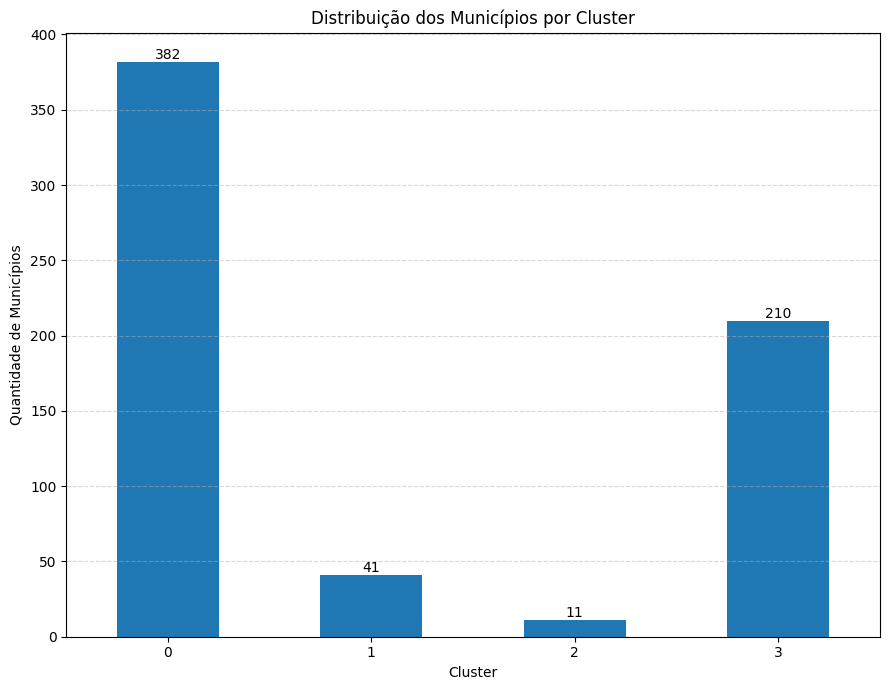

In [46]:
plt.figure(figsize=(9, 7))

ax = (
    df_without_sp["cluster"]
    .value_counts()
    .sort_index()
    .plot(kind="bar")
)

plt.title("Distribuição dos Municípios por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de Municípios")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for barra in ax.patches:
    altura = barra.get_height()

    ax.annotate(
        f"{int(altura)}",
        (
            barra.get_x() + barra.get_width() / 2,
            altura
        ),
        ha="center",
        va="bottom",
        fontsize=10
    )
    
plt.tight_layout()
plt.show()

### 11. Scatterplot

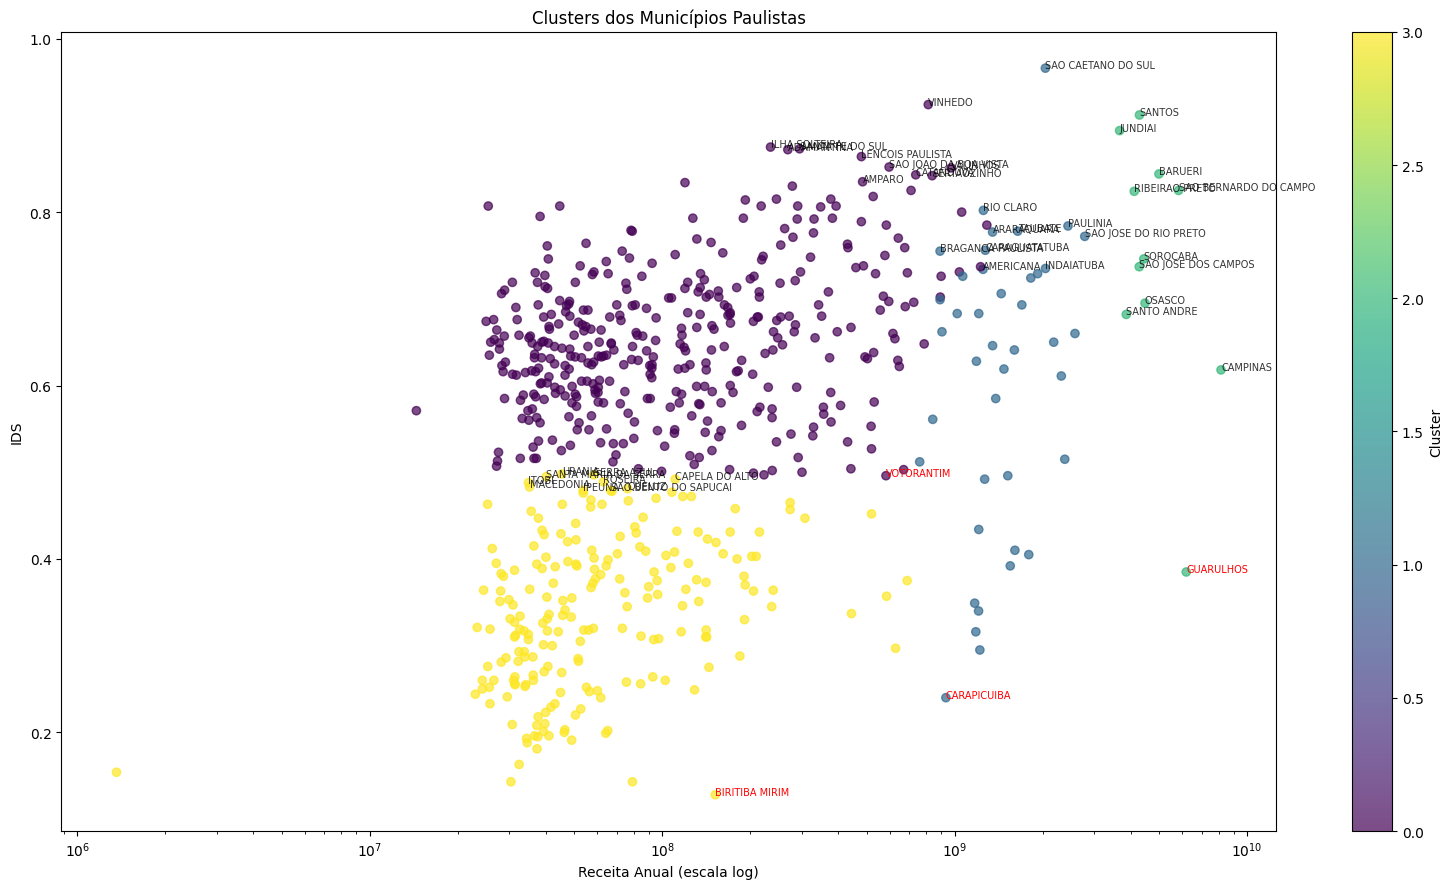

In [47]:
plt.figure(figsize=(16, 9))

scatter = plt.scatter(
    df_without_sp["receita_anual"],
    df_without_sp["ids"],
    c=df_without_sp["cluster"],
    alpha=0.7
)

plt.xscale("log")

# Mostrar os 10 melhores municípios de cada cluster
for cluster in sorted(df_without_sp["cluster"].unique()):

    top10 = (
        df_without_sp[df_without_sp["cluster"] == cluster]
        .nlargest(10, "ids")
    )

    for _, row in top10.iterrows():
        plt.annotate(
            row["municipio"],
            (row["receita_anual"], row["ids"]),
            fontsize=7,
            alpha=0.8
        )


    bottom = (
        df_without_sp[df_without_sp["cluster"] == cluster]
        .nsmallest(1, "ids")
    )


    for _, row in bottom.iterrows():
        plt.annotate(
            row["municipio"],
            (row["receita_anual"], row["ids"]),
            fontsize=7,
            color="red"
        )

plt.title("Clusters dos Municípios Paulistas")
plt.xlabel("Receita Anual (escala log)")
plt.ylabel("IDS")
plt.colorbar(scatter, label="Cluster")

plt.tight_layout()
plt.show()

## Conclusões

aaaa